# ADNI no-MCI CN/AD latent classifier

This notebook trains a standard MLP on the 256D subject latent vectors from the longitudinal model.

- Train split: learned subject anchors from `LatentCodes/1000.pth`
- Validation/test splits: subject anchors fitted from observed scans with the same decoder/flow checkpoint
- Runs: three random seeds
- Target: binary CN vs AD (`label_ad`: 0 = CN, 1 = AD)

If you want an earlier-observation classifier, change `OBSERVATION_MODE` to `"baseline_only"`.


The notebook saves CSV and JSON outputs under `analysis/latent_classifier/`.


In [1]:
import os
from pathlib import Path
import sys

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve

EXPERIMENT_DIR = Path("/home/jakaria/INR/Deep3DComp/examples/ADNI_1_L_No_MCI/longitudinal_age_disease_conditioned_cocycle_shape_multiple_pairs_real_pair_shape_reconstruction")
if str(EXPERIMENT_DIR) not in sys.path:
    sys.path.insert(0, str(EXPERIMENT_DIR))

import adni_no_mci_latent_classifier_helpers as clf

CHECKPOINT = "1000"
OBSERVATION_MODE = "all"
DEVICE = "auto"

ANCHOR_FIT_STEPS = 50
ANCHOR_FIT_SAMPLES = 512
ANCHOR_FIT_LR = 5e-3

SEEDS = (0, 1, 2)
CLASSIFIER_HIDDEN_DIMS = (128, 64)
DROPOUT = 0.2
BATCH_SIZE = 32
LR = 1e-3
WEIGHT_DECAY = 1e-4
MAX_EPOCHS = 200
PATIENCE = 25
THRESHOLD = 0.5

OUTPUT_DIR = clf.ensure_output_dir()
print("Experiment dir:", EXPERIMENT_DIR)
print("Output dir:", OUTPUT_DIR)


Experiment dir: /home/jakaria/INR/Deep3DComp/examples/ADNI_1_L_No_MCI/longitudinal_age_disease_conditioned_cocycle_shape_multiple_pairs_real_pair_shape_reconstruction
Output dir: /home/jakaria/INR/Deep3DComp/examples/ADNI_1_L_No_MCI/longitudinal_age_disease_conditioned_cocycle_shape_multiple_pairs_real_pair_shape_reconstruction/analysis/latent_classifier


In [2]:
splits = clf.prepare_latent_splits(
    checkpoint=CHECKPOINT,
    device=DEVICE,
    observation_mode=OBSERVATION_MODE,
    anchor_fit_steps=ANCHOR_FIT_STEPS,
    anchor_fit_samples=ANCHOR_FIT_SAMPLES,
    anchor_fit_lr=ANCHOR_FIT_LR,
    seed=0,
)

for split_name in ("train", "val", "test"):
    split = splits[split_name]
    frame = split["frame"]
    X = split["X"]
    y = split["y"]
    print(
        f"{split_name}: subjects={len(frame)}  features={X.shape}  "
        f"CN={(y == 0).sum()}  AD={(y == 1).sum()}"
    )
    display(
        frame[
            [
                "subject_id",
                "diagnosis",
                "n_scans",
                "baseline_age_years",
                "age_span_years",
                "latent_source",
            ]
        ].head(5)
    )


[latent] loaded train latents from checkpoint 1000: 207 subjects x 256 dims
[latent] fitting val latents from checkpoint 1000: 13 subjects, observation_mode=all
[latent:val] 1/13 subject=003_S_0907
[latent:val] 2/13 subject=011_S_0016
[latent:val] 3/13 subject=011_S_0022
[latent:val] 4/13 subject=013_S_1205
[latent:val] 5/13 subject=022_S_0096
[latent:val] 6/13 subject=023_S_0061
[latent:val] 7/13 subject=023_S_1190
[latent:val] 8/13 subject=057_S_1373
[latent:val] 9/13 subject=098_S_0149
[latent:val] 10/13 subject=114_S_0173
[latent:val] 11/13 subject=126_S_0680
[latent:val] 12/13 subject=126_S_0784
[latent:val] 13/13 subject=133_S_0525
[latent] fitting test latents from checkpoint 1000: 24 subjects, observation_mode=all
[latent:test] 1/24 subject=002_S_0413
[latent:test] 2/24 subject=003_S_0981
[latent:test] 3/24 subject=005_S_0553
[latent:test] 4/24 subject=009_S_0751
[latent:test] 5/24 subject=011_S_0003
[latent:test] 6/24 subject=021_S_0642
[latent:test] 7/24 subject=022_S_0014
[l

,subject_id,diagnosis,n_scans,baseline_age_years,age_span_years,latent_source
0,002_S_0295,CN,3,85.0,1.0,trained_latent_checkpoint_1000
1,002_S_0619,AD,3,78.0,1.0,trained_latent_checkpoint_1000
2,002_S_0685,CN,3,90.0,1.0,trained_latent_checkpoint_1000
3,002_S_0938,AD,3,82.0,1.0,trained_latent_checkpoint_1000
4,002_S_1018,AD,3,71.0,1.0,trained_latent_checkpoint_1000


val: subjects=13  features=(13, 256)  CN=9  AD=4


,subject_id,diagnosis,n_scans,baseline_age_years,age_span_years,latent_source
0,013_S_1205,AD,3,83.0,1.0,fitted_all_checkpoint_1000
1,057_S_1373,AD,3,75.0,1.0,fitted_all_checkpoint_1000
2,098_S_0149,AD,3,88.0,1.0,fitted_all_checkpoint_1000
3,126_S_0784,AD,3,76.0,1.0,fitted_all_checkpoint_1000
4,003_S_0907,CN,3,89.0,1.0,fitted_all_checkpoint_1000


test: subjects=24  features=(24, 256)  CN=15  AD=9


,subject_id,diagnosis,n_scans,baseline_age_years,age_span_years,latent_source
0,011_S_0003,AD,3,81.0,1.0,fitted_all_checkpoint_1000
1,021_S_0642,AD,3,85.0,1.0,fitted_all_checkpoint_1000
2,023_S_1262,AD,3,73.0,1.0,fitted_all_checkpoint_1000
3,033_S_1281,AD,3,78.0,1.0,fitted_all_checkpoint_1000
4,033_S_1283,AD,3,60.0,1.0,fitted_all_checkpoint_1000


In [3]:
result = clf.run_three_seed_latent_classifier_from_splits(
    splits=splits,
    checkpoint=CHECKPOINT,
    observation_mode=OBSERVATION_MODE,
    seeds=SEEDS,
    hidden_dims=CLASSIFIER_HIDDEN_DIMS,
    dropout=DROPOUT,
    batch_size=BATCH_SIZE,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
    threshold=THRESHOLD,
    device=DEVICE,
)

saved_dir = clf.save_latent_classifier_outputs(result, OUTPUT_DIR)
print("Saved outputs to:", saved_dir)


[classifier] training seed=0
[classifier] seed=0 done | best_epoch=2 | test_acc=0.6250 | test_auc=0.3704
[classifier] training seed=1
[classifier] seed=1 done | best_epoch=1 | test_acc=0.5417 | test_auc=0.4741
[classifier] training seed=2
[classifier] seed=2 done | best_epoch=3 | test_acc=0.5417 | test_auc=0.4889
Saved outputs to: /home/jakaria/INR/Deep3DComp/examples/ADNI_1_L_No_MCI/longitudinal_age_disease_conditioned_cocycle_shape_multiple_pairs_real_pair_shape_reconstruction/analysis/latent_classifier


In [4]:
display(result["seed_results"].round(4))
display(result["summary"].round(4))
display(result["predictions"].query("split == 'test'").head(20))


,seed,best_epoch,best_val_loss,train_accuracy,train_balanced_accuracy,train_f1,train_precision,train_recall,train_specificity,train_roc_auc,...,test_f1,test_precision,test_recall,test_specificity,test_roc_auc,test_average_precision,test_tn,test_fp,test_fn,test_tp
0,0,2,0.7605,0.9614,0.9590,0.9540,0.9651,0.9432,0.9748,0.9948,...,0.0000,0.0000,0.0000,1.0000,0.3704,0.4016,15.0,0.0,9.0,0.0
1,1,1,0.7840,0.8551,0.8369,0.8077,0.9265,0.7159,0.9580,0.9123,...,0.3529,0.3750,0.3333,0.6667,0.4741,0.5098,10.0,5.0,6.0,3.0
2,2,3,0.7410,0.9952,0.9958,0.9944,0.9888,1.0000,0.9916,0.9999,...,0.4762,0.4167,0.5556,0.5333,0.4889,0.4063,8.0,7.0,4.0,5.0


,metric,mean,std,min,max
0,test_accuracy,0.5694,0.0393,0.5417,0.6250
1,test_average_precision,0.4392,0.0499,0.4016,0.5098
2,test_balanced_accuracy,0.5148,0.0210,0.5000,0.5444
3,test_f1,0.2764,0.2018,0.0000,0.4762
4,test_fn,6.3333,2.0548,4.0000,9.0000
5,test_fp,4.0000,2.9439,0.0000,7.0000
6,test_precision,0.2639,0.1874,0.0000,0.4167
7,test_recall,0.2963,0.2283,0.0000,0.5556
8,test_roc_auc,0.4444,0.0527,0.3704,0.4889
9,test_specificity,0.7333,0.1963,0.5333,1.0000


,split,label_ad_true,label_ad_prob,label_ad_pred,subject_id,diagnosis,n_scans,baseline_age_years,age_span_years,latent_source,latent_fit_loss_end,seed
220,test,1,0.306859,0,011_S_0003,AD,3,81.0,1.0,fitted_all_checkpoint_1000,0.006763,0
221,test,1,0.391176,0,021_S_0642,AD,3,85.0,1.0,fitted_all_checkpoint_1000,0.005728,0
222,test,1,0.373870,0,023_S_1262,AD,3,73.0,1.0,fitted_all_checkpoint_1000,0.005520,0
223,test,1,0.403851,0,033_S_1281,AD,3,78.0,1.0,fitted_all_checkpoint_1000,0.006291,0
224,test,1,0.484716,0,033_S_1283,AD,3,60.0,1.0,fitted_all_checkpoint_1000,0.007865,0
225,test,1,0.422004,0,062_S_0730,AD,3,71.0,1.0,fitted_all_checkpoint_1000,0.005064,0
226,test,1,0.459815,0,067_S_0076,AD,3,78.0,1.0,fitted_all_checkpoint_1000,0.006345,0
227,test,1,0.418924,0,136_S_0299,AD,3,89.0,1.0,fitted_all_checkpoint_1000,0.005864,0
228,test,1,0.430289,0,141_S_0853,AD,2,87.0,0.5,fitted_all_checkpoint_1000,0.006587,0
229,test,0,0.470434,0,002_S_0413,CN,3,76.0,1.0,fitted_all_checkpoint_1000,0.006591,0


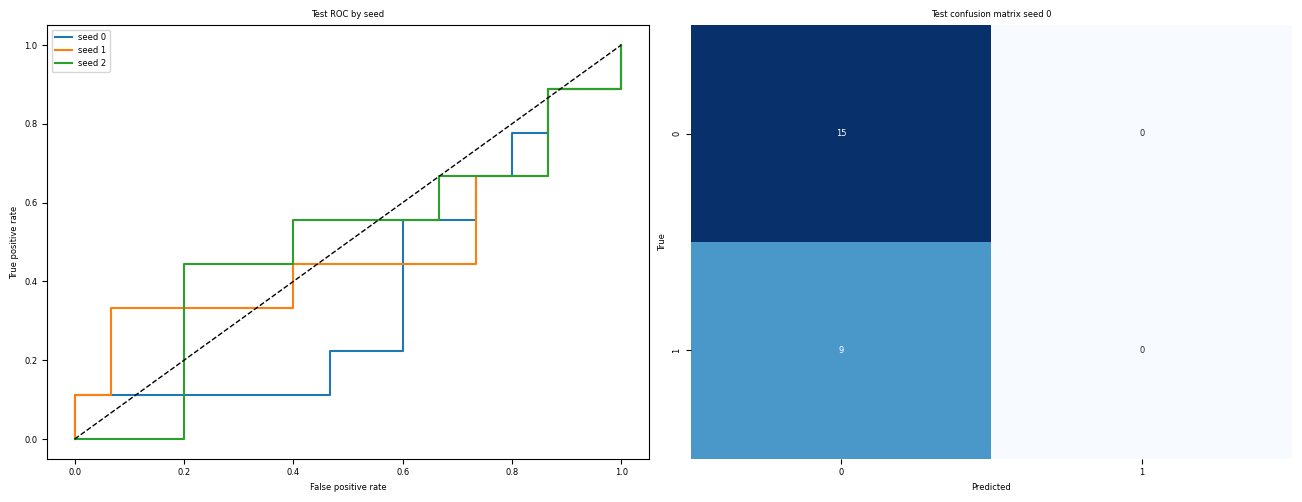

In [5]:
test_pred = result["predictions"].query("split == 'test'").copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for seed in sorted(test_pred["seed"].unique()):
    frame = test_pred[test_pred["seed"] == seed]
    fpr, tpr, _ = roc_curve(frame["label_ad_true"], frame["label_ad_prob"])
    axes[0].plot(fpr, tpr, label=f"seed {seed}")
axes[0].plot([0, 1], [0, 1], "k--", linewidth=1)
axes[0].set_title("Test ROC by seed")
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].legend()

seed = sorted(test_pred["seed"].unique())[0]
frame = test_pred[test_pred["seed"] == seed]
cm = confusion_matrix(frame["label_ad_true"], frame["label_ad_pred"], labels=[0, 1])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[1])
axes[1].set_title(f"Test confusion matrix seed {seed}")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

plt.tight_layout()
